In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
gdsc = pd.read_excel("../data/gdsc.xlsx")

In [9]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [10]:
gdsc.shape # 162103 entries with 19 variables

(162103, 19)

In [11]:
gdsc.columns

Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1',
       'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)',
       'Microsatellite instability Status (MSI)', 'Screen Medium',
       'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET',
       'TARGET_PATHWAY'],
      dtype='str')

In [12]:
gdsc.info()

<class 'pandas.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  str    
 2   TCGA_DESC                                162103 non-null  str    
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  str    
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  str    
 9   GDSC Tissue descriptor 2                 162103 non-null  str    
 10  Cancer Type (matching TCGA label)        16

In [13]:
gdsc.isnull().sum() #no zero values in all the columns

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [14]:
for col in gdsc.columns:
    n_unique = gdsc[col].nunique()
    dtype = gdsc[col].dtype
    if n_unique <= 40:
        print(f"{col} ({dtype}) -> {list(gdsc[col].unique())}")
    else:
        print(f"{col} ({dtype}) -> {n_unique} unique values")

COSMIC_ID (int64) -> 737 unique values
CELL_LINE_NAME (str) -> 737 unique values
TCGA_DESC (str) -> ['MB', 'SKCM', 'BLCA', 'CESC', 'GBM', 'LUAD', 'LUSC', 'SCLC', 'MESO', 'NB', 'MM', 'PAAD', 'ESCA', 'BRCA', 'HNSC', 'KIRC', 'LAML', 'OV', 'PRAD', 'COREAD', 'LCML', 'ALL', 'LGG', 'THCA', 'STAD', 'DLBC', 'UCEC', 'LIHC', 'CLL', 'ACC']
DRUG_ID (int64) -> 254 unique values
DRUG_NAME (str) -> 246 unique values
LN_IC50 (float64) -> 159646 unique values
AUC (float64) -> 109624 unique values
Z_SCORE (float64) -> 158203 unique values
GDSC Tissue descriptor 1 (str) -> ['nervous_system', 'skin', 'urogenital_system', 'lung_NSCLC', 'lung_SCLC', 'lung', 'neuroblastoma', 'myeloma', 'pancreas', 'aero_dig_tract', 'breast', 'kidney', 'leukemia', 'large_intestine', 'thyroid', 'digestive_system', 'lymphoma']
GDSC Tissue descriptor 2 (str) -> ['medulloblastoma', 'melanoma', 'Bladder', 'cervix', 'glioma', 'lung_NSCLC_adenocarcinoma', 'lung_NSCLC_squamous_cell_carcinoma', 'lung_small_cell_carcinoma', 'mesotheliom

In [15]:
gdsc.columns = gdsc.columns.str.strip()

In [16]:
gdsc.columns =gdsc.columns.str.replace(" ", "_")

In [17]:
#coverting the columns to float values
gdsc['LN_IC50'] = pd.to_numeric(gdsc['LN_IC50'], errors='coerce')
gdsc['AUC'] = pd.to_numeric(gdsc['AUC'], errors='coerce')

In [18]:
#checking geh effects of the conversion
gdsc[['LN_IC50', 'AUC']].isnull().sum()

LN_IC50    0
AUC        0
dtype: int64

In [19]:
#Standardising binary columns ot avoid Y,N Yes,No
binary_cols = ['CNA', 'Gene_Expression', 'Methylation']

for col in binary_cols:
    gdsc[col] = gdsc[col].astype(str).str.strip().str.upper()

In [20]:
#Sanity check for standardisaiton
for col in binary_cols:
    print(col, gdsc[col].unique())

CNA <StringArray>
['Y', 'N']
Length: 2, dtype: str
Gene_Expression <StringArray>
['Y', 'N']
Length: 2, dtype: str
Methylation <StringArray>
['Y', 'N']
Length: 2, dtype: str


In [21]:
#Converting binary responses to categories 
for col in binary_cols:
    gdsc[col] = gdsc[col].astype('category')

In [22]:
gdsc.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.621030e+05,162103.000000,162103.000000,162103.000000,162103.000000
mean,9.857634e+05,1554.527603,2.822644,0.879924,0.037711
std,2.240213e+05,406.964712,2.836231,0.148592,0.999098
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716
25%,9.059780e+05,1086.000000,1.476170,0.845967,-0.615884
50%,9.092570e+05,1598.000000,3.271447,0.941467,0.048930
75%,1.240143e+06,1910.000000,4.767629,0.973917,0.686466
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776


In [23]:

gdsc['Cancer_Type_(matching_TCGA_label)'].value_counts().head(10)

Cancer_Type_(matching_TCGA_label)
LUAD         13300
SCLC         11938
BRCA         11166
SKCM         10661
COAD/READ    10531
ESCA          7919
HNSC          7738
GBM           7403
OV            7237
DLBC          7003
Name: count, dtype: int64

In [24]:
gdsc['Microsatellite_instability_Status_(MSI)'].value_counts()

Microsatellite_instability_Status_(MSI)
MSS/MSI-L    150781
MSI-H         11322
Name: count, dtype: int64

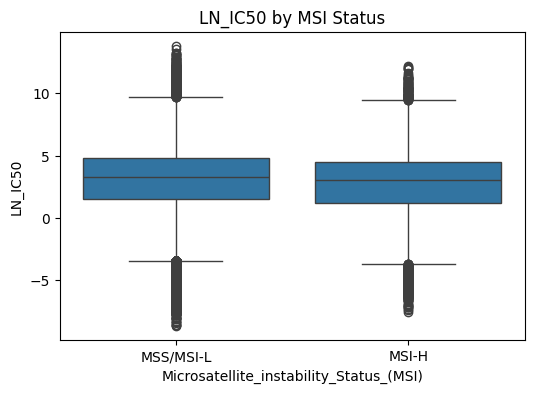

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=gdsc,
    x='Microsatellite_instability_Status_(MSI)',
    y='LN_IC50'
)
plt.title("LN_IC50 by MSI Status")
plt.show()

In [26]:
gdsc.shape


(162103, 19)

In [27]:

gdsc['Microsatellite_instability_Status_(MSI)'].value_counts()

Microsatellite_instability_Status_(MSI)
MSS/MSI-L    150781
MSI-H         11322
Name: count, dtype: int64

In [28]:
gdsc['DRUG_NAME'].nunique()
#246 unique drug names

246

In [29]:
gdsc['TARGET_PATHWAY'].nunique()
#23 unique target pathways

23

In [30]:
gdsc['TARGET'].nunique()
#183 unique target sites.

183

In [31]:
gdsc[['LN_IC50', 'AUC']].describe()

,LN_IC50,AUC
count,162103.000000,162103.000000
mean,2.822644,0.879924
std,2.836231,0.148592
min,-8.642551,0.006282
25%,1.476170,0.845967
50%,3.271447,0.941467
75%,4.767629,0.973917
max,13.820189,0.998904


In [32]:
gdsc['COSMIC_ID'].nunique()
#737 unique cosmic IDs. Does this mean some entries are repeated? 
#If yes what does this mean for our analyses?
## Multiple drugs were tested on multiple cell lines.

737

In [33]:
gdsc['CELL_LINE_NAME'].nunique()
#737 unique Cell line names. Does this mean some entries are repeated? If yes what does this mean for our anlysis?

737

In [34]:
gdsc['GDSC_Tissue_descriptor_1'].nunique()
#17 unique system descriptors. 

17

In [35]:
gdsc['GDSC_Tissue_descriptor_2'].nunique()
#737 unique organ descriptors. 

33

In [36]:
#Sanity check

for col in ['CNA', 'Gene_Expression', 'Methylation']:
    print(col, gdsc[col].value_counts())

CNA CNA
Y    161445
N       658
Name: count, dtype: int64
Gene_Expression Gene_Expression
Y    158342
N      3761
Name: count, dtype: int64
Methylation Methylation
Y    158601
N      3502
Name: count, dtype: int64


In [37]:
gdsc['Microsatellite_instability_Status_(MSI)'].value_counts()

Microsatellite_instability_Status_(MSI)
MSS/MSI-L    150781
MSI-H         11322
Name: count, dtype: int64

In [38]:
2

2

In [39]:
#Checking for duplicates from the cosmic id issue
gdsc.duplicated(subset=['CELL_LINE_NAME', 'DRUG_NAME']).sum()

np.int64(4290)

In [40]:
# 4290 duplicates were found meaning there were 4290 lines which had the same cosmic id and drug name combination

In [41]:
#Checking for variations in the other columns for the duplicate combinations
cols_to_check = [
    'Microsatellite_instability_Status_(MSI)',
    'CNA',
    'Gene_Expression',
    'Methylation',
    'Screen_Medium',
    'Growth_Properties',
    'TARGET',
    'TARGET_PATHWAY'
]

gdsc.groupby(['COSMIC_ID', 'DRUG_NAME'])[cols_to_check].nunique().max()

Microsatellite_instability_Status_(MSI)    1
CNA                                        1
Gene_Expression                            1
Methylation                                1
Screen_Medium                              1
Growth_Properties                          1
TARGET                                     1
TARGET_PATHWAY                             1
dtype: int64

In [42]:
# Suggestion is to merge the cells with uniques cell line name and drug combinations while averaging continuous values.

In [43]:
drug_response = (
    gdsc
    .groupby(['COSMIC_ID', 'DRUG_NAME'], as_index=False)
    .agg({
        'LN_IC50': 'mean',
        'AUC': 'mean',
        'Z_SCORE': 'mean'
    })
)


In [44]:
cell_line_meta = (
    gdsc
    .drop_duplicates('COSMIC_ID')[[
        'COSMIC_ID',
        'Microsatellite_instability_Status_(MSI)',
        'CNA',
        'Gene_Expression',
        'Methylation',
        'Screen_Medium',
        'Growth_Properties',
        'Cancer_Type_(matching_TCGA_label)',
        'TCGA_DESC'
    ]]
)

In [45]:
gdsc_clean = drug_response.merge(cell_line_meta, on='COSMIC_ID')

In [46]:
gdsc_clean.shape


(157813, 13)

In [47]:
gdsc_clean.head()

,COSMIC_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,Microsatellite_instability_Status_(MSI),CNA,Gene_Expression,Methylation,Screen_Medium,Growth_Properties,Cancer_Type_(matching_TCGA_label),TCGA_DESC
0,683667,5-Fluorouracil,5.569870,0.974115,0.689678,MSS/MSI-L,Y,Y,Y,R,Adherent,MB,MB
1,683667,ABT737,0.008803,0.647661,-0.910232,MSS/MSI-L,Y,Y,Y,R,Adherent,MB,MB
2,683667,AGI-5198,4.265332,0.969221,-0.481199,MSS/MSI-L,Y,Y,Y,R,Adherent,MB,MB
3,683667,AGI-6780,4.288473,0.969760,-0.049603,MSS/MSI-L,Y,Y,Y,R,Adherent,MB,MB
4,683667,AMG-319,4.211545,0.967933,-0.495704,MSS/MSI-L,Y,Y,Y,R,Adherent,MB,MB


In [48]:
gdsc_clean.duplicated(subset=['COSMIC_ID', 'DRUG_NAME']).sum()

np.int64(0)